# Bandwidth of Rubidum D2
Plot of the bandwidth of a cavity with respect to the output coupler and the cavity length

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

In [33]:
from utils.plot_style import set_plot_style

set_plot_style()

In [34]:
import optics.formulas_cavity as fc

In [35]:
colors = ["orange", "yellow", "white", "lightblue", "darkblue"]
map = LinearSegmentedColormap.from_list("blue_purple_flag", colors)

# Diverging: purple -> white -> green
diverging_cmap = LinearSegmentedColormap.from_list(
    "custom_diverging",
    [
        (118/255, 42/255, 131/255),   # purple
        (247/255, 247/255, 247/255),  # white
        (27/255,  120/255, 55/255),   # green
    ]
)

# Sequential: cream -> orange -> dark brown
sequential_cmap = LinearSegmentedColormap.from_list(
    "custom_sequential",
    [
        (255/255, 225/255, 229/255),  # cream
        (251/255, 154/255, 41/255),   # orange
        (102/255, 37/255,  6/255),    # dark brown
    ]
)


In [36]:
map = diverging_cmap

### Set parameters

In [68]:
N = 1000

cavity_lengths = np.linspace(start=0.4, stop=1.6, num=N)  # 500mm to 1200mm

transmission_coefficients = np.linspace(start=0.03, stop=0.15, num=N)  # 5% to 15%

L, T = np.meshgrid(cavity_lengths, transmission_coefficients)

In [69]:
# Define the target bandwidth range
target_bandwidth = 6.0  # 6 MHz
tolerance = 0.1  # ±10%

bandwidth_min = target_bandwidth * (1 - tolerance)
bandwidth_max = target_bandwidth * (1 + tolerance)

In [70]:
# Loss inside cavity
loss = 0.02

### Compute bandwidth

In [71]:
# Bow-tie
bandwidth_meshgrid = fc.bandwidth(fsr=fc.FSR_bowtie(L), finesse=fc.Finesse(T=T, Loss=loss)) * 1e-6  # MHz

In [50]:
# Linear
bandwidth_meshgrid = fc.bandwidth(fsr=fc.FSR_linear(L), finesse=fc.Finesse(T=T, Loss=loss)) * 1e-6  # MHz

In [72]:
# Mask the region outside the desired range
mask = (bandwidth_meshgrid < bandwidth_min) | (bandwidth_meshgrid > bandwidth_max)
masked_bandwidth = np.ma.masked_array(bandwidth_meshgrid, mask)


### Litterature values

In [73]:
# Define experimental data (copy-paste into a notebook cell)
experimental_points = [
    # SHG (circle)
    (0.790, 0.12, "SHG", "Burks"),
    (0.600, 0.18, "SHG", "Hetet"),
    # OPO (star)
    (0.550, 0.07, "OPO", "Burks"),
    (0.600, 0.08, "OPO", "Hetet"),
    (0.214, 0.15, "OPO", "Aoki"),
    (0.600, 0.115, "OPO", "Han"),
]

### Plot

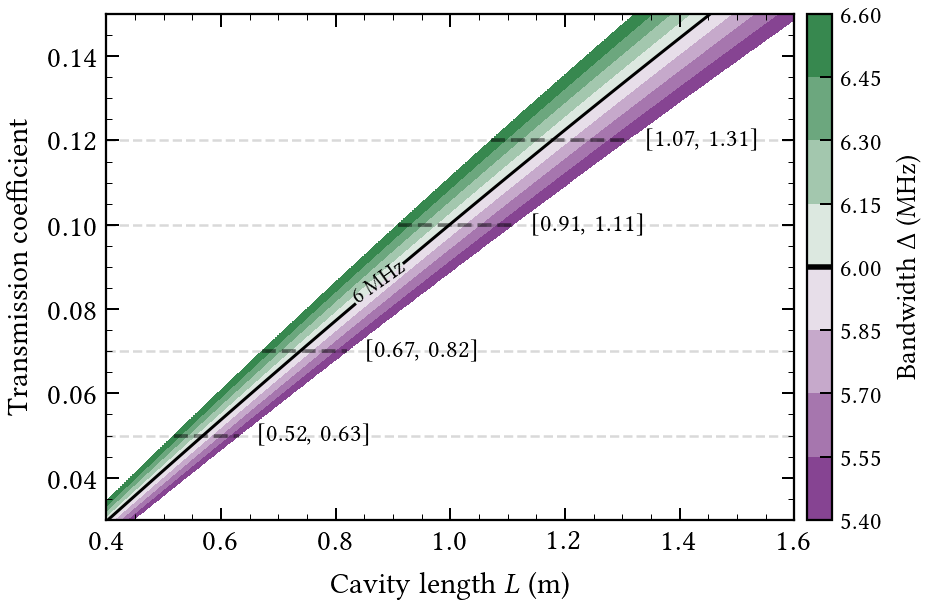

In [76]:
target_bw = 6.0  # MHz

fig, ax = plt.subplots()

# Heatmap
contour = ax.contourf(
    L,
    T,
    masked_bandwidth,
    levels=10,
    cmap=map,
)

# ------------------------------------------------------------------
# Exact 6 MHz contour
# ------------------------------------------------------------------
iso = ax.contour(
    L,
    T,
    masked_bandwidth,
    levels=[target_bw],
    colors="black",
    linewidths=1.2,
    linestyles="-",
)

# Get the contour line vertices
path = iso.collections[0].get_paths()[0]
vertices = path.vertices
mid_x = np.mean(vertices[:, 0])
mid_y = np.mean(vertices[:, 1])

# # Optional inline label on the contour itself
MH_label = ax.clabel(
    iso,
    fmt={target_bw: r"$6\,\mathrm{MHz}$"},
    fontsize=9,
    colors="black",
    manual=[(0.95*mid_x, 0.95*mid_y)]
)
#-------------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------------
cbar = plt.colorbar(contour, ax=ax, pad=0.015)

cbar.set_label(
    r"Bandwidth $\Delta$ (MHz)",
    fontsize=11,
)

cbar.ax.tick_params(labelsize=10)

# Add horizontal marker on colorbar at 6 MHz
cbar.ax.axhline(
    target_bw,
    color="black",
    linewidth=2.2,
)

# ------------------------------------------------------------------
# Existing transmission guide lines
# ------------------------------------------------------------------
T_values = [0.05, 0.07, 0.10, 0.12]
bw_min, bw_max = 5.4, 6.6

for T_value in T_values:

    bw_line = fc.bandwidth(
        fsr=fc.FSR_bowtie(cavity_lengths),
        finesse=fc.Finesse(T=T_value, Loss=loss)
    ) * 1e-6

    valid = (bw_line >= bw_min) & (bw_line <= bw_max)
    valid_lengths = cavity_lengths[valid]

    ax.plot(
        cavity_lengths,
        [T_value] * len(cavity_lengths),
        color="black",
        linestyle="--",
        linewidth=1.0,
        alpha=0.15,
    )

    if valid_lengths.size > 0:

        ax.plot(
            valid_lengths,
            [T_value] * len(valid_lengths),
            color="black",
            linestyle="--",
            linewidth=1.5,
            alpha=0.45,
        )

        L_min, L_max = valid_lengths[0], valid_lengths[-1]

        # Threshold: if the valid range ends close to the right edge of the plot
        L_plot_max = cavity_lengths[-1]
        margin = 0.1 * (L_plot_max - cavity_lengths[0])  # % of total range

        if (L_plot_max - L_max) < margin:
            # Too close to right edge → place label on the left
            x_text = L_min
            ha = "right"
            x_offset = -8
        else:
            # Enough room → place label on the right
            x_text = L_max
            ha = "left"
            x_offset = 8

        ax.annotate(
            rf"$[{L_min:.2f},\, {L_max:.2f}]$",
            xy=(x_text, T_value),
            xytext=(x_offset, 0),
            textcoords="offset points",
            ha=ha,
            va="center",
            fontsize=10,
            color="black",
        )

# for i, (L, T, typ, author) in enumerate(experimental_points, 1):
#     marker = 'o' if typ == 'SHG' else '*'
#     ax.scatter(L, T, s=90, marker=marker, color='black', zorder=10)
#     ax.text(L + 0.005, T + 0.002, str(i), color='black', fontsize=9,
#             ha='left', va='bottom', zorder=10)
#
# # Add legend
# ax.legend(
#     handles=[
#         Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='SHG', linestyle='None'),
#         Line2D([0], [0], marker='*', color='w', markerfacecolor='black', markersize=10, label='OPO', linestyle='None')
#     ],
#     loc='upper right',
#     fontsize=10
# )

ax.set_xlabel(r"Cavity length $L$ (m)")
ax.set_ylabel(r"Transmission coefficient")

plt.show()

In [78]:
fig.savefig("bandwidth_cavity.svg", dpi=300)